# Quickstart notebook (InflationEasy)

This notebook is a guided, self-running workflow.

It is currently configured to:
- run a small analytical inflation example (default `N = 64`, editable below),
- explicitly disable `GW` and `deltaN` (unless you switch them on below),
- keep the run light enough for laptop testing,
- save outputs in a dedicated folder,
- and plot some of the summary statistics.


## What this notebook does (step by step)

1. Explains which parameters require recompilation and which do not.
2. Patches compile-time parameters in `src/parameters.h`.
3. Writes `params.txt` from the analytical preset plus your runtime overrides.
4. Builds and runs `./inflation_easy` in lightweight inflation-only mode by default.
5. Loads outputs and plots summary diagnostics.
6. At the end, explains exactly how to switch features/examples.


In [1]:
# Install Python plotting dependencies (safe to run again)
%pip -q install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


## Compile-time vs run-time parameters (important)

- **Compile-time parameters** (in `src/parameters.h`): require recompilation (`make`).
  - Examples: `N`, `numerical_potential`, `perform_deltaN`, `calculate_SIGW`, `post_inflation`, `parallel_calculation`.
- **Run-time parameters** (in `params.txt`): no recompilation needed.
  - Examples: `dt`, `output_freq`, `omega`, `af_post_inflation`, output toggles.

This notebook keeps these two categories separate and explicit.


In [2]:
import io
import os
import re
import shlex
import shutil
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# Same style setup as plot.ipynb
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / 'src' / 'parameters.h').exists() and (p / 'Makefile').exists():
            return p
    raise RuntimeError('Could not find InflationEasy repository root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
PARAMETERS_H = REPO_ROOT / 'src' / 'parameters.h'
PARAMS_TXT = REPO_ROOT / 'params.txt'

print(f'Repository root: {REPO_ROOT}')

Repository root: /Users/caravano/Desktop/Projects/inflation-easy


## User configuration

This notebook runs only the **analytical** example by default.

Edit values below if needed, then continue top-to-bottom.

In [3]:
# --------------------------
# Compile-time configuration
# --------------------------
# These changes REQUIRE recompilation.
COMPILE_CONFIG = {
    'N': 64,  # default for quick runs; change freely
    'numerical_potential': 0,   # 0 = analytical potential (default in this notebook)
    'perform_deltaN': 0,
    'calculate_SIGW': 0,
    'post_inflation': 0,
    'parallel_calculation': 1,
}

# -----------------------
# Run-time configuration
# -----------------------
# These changes DO NOT require recompilation.
# Defaults are taken from params.analytic.txt, then overrides are applied.
RUNTIME_OVERRIDES = {
    'seed': 10,         # explicit random seed for reproducibility
    'output_box2D': 1,   # keep 2D scalar-field snapshots
}

CASE_NAME = 'analytical_hilltop_N64'
PRESET_FILE = 'params.analytic.txt'
RESTORE_ORIGINAL_FILES_AT_END = True

PEDAGOGICAL_RUNS_DIR = REPO_ROOT / 'pedagogical_runs'
CASE_DIR = PEDAGOGICAL_RUNS_DIR / CASE_NAME
RESULTS_DIR = CASE_DIR / 'results'

## Build and run helpers

These utility functions patch files safely, execute shell commands, and preserve backups.

In [4]:
BACKUP_DIR = REPO_ROOT / '.pedagogical_backup'
BACKUP_DIR.mkdir(exist_ok=True)


def backup_file(path: Path):
    shutil.copy2(path, BACKUP_DIR / (path.name + '.bak'))


def restore_file(path: Path):
    src = BACKUP_DIR / (path.name + '.bak')
    if src.exists():
        shutil.copy2(src, path)


def run_cmd(cmd, cwd=None, tee_to=None):
    cmd_list = shlex.split(cmd) if isinstance(cmd, str) else cmd
    print(f"\n$ {' '.join(shlex.quote(x) for x in cmd_list)}")

    proc = subprocess.Popen(
        cmd_list,
        cwd=str(cwd) if cwd else None,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    with (open(tee_to, 'w', encoding='utf-8') if tee_to else open(os.devnull, 'w', encoding='utf-8')) as logf:
        for line in proc.stdout:
            print(line, end='')
            if tee_to:
                logf.write(line)

    code = proc.wait()
    if code != 0:
        raise RuntimeError(f"Command failed with exit code {code}: {' '.join(cmd_list)}")


def set_define(text: str, name: str, value: int) -> str:
    pattern = rf'(?m)^#define\s+{re.escape(name)}\s+[-+]?\d+\s*$'
    repl = f'#define {name} {int(value)}'
    if not re.search(pattern, text):
        raise RuntimeError(f'Could not find #define for {name}')
    return re.sub(pattern, repl, text, count=1)


def set_const_N(text: str, N_value: int) -> str:
    pattern = r'(?m)^const\s+int\s+N\s*=\s*\d+\s*;\s*$'
    repl = f'const int N = {int(N_value)};'
    if not re.search(pattern, text):
        raise RuntimeError('Could not find const int N declaration')
    return re.sub(pattern, repl, text, count=1)


def apply_compile_config(config: dict):
    txt = PARAMETERS_H.read_text(encoding='utf-8')
    txt = set_const_N(txt, config['N'])
    for k in ['numerical_potential', 'perform_deltaN', 'calculate_SIGW', 'post_inflation', 'parallel_calculation']:
        txt = set_define(txt, k, config[k])
    PARAMETERS_H.write_text(txt, encoding='utf-8')


def parse_params_lines(path: Path):
    lines = path.read_text(encoding='utf-8').splitlines()
    key_to_idx = {}
    for i, line in enumerate(lines):
        raw = line.split('#', 1)[0].strip()
        if not raw or '=' not in raw:
            continue
        key = raw.split('=', 1)[0].strip()
        key_to_idx[key] = i
    return lines, key_to_idx


def write_params_from_preset(preset_path: Path, out_path: Path, overrides: dict):
    shutil.copy2(preset_path, out_path)
    lines, key_to_idx = parse_params_lines(out_path)
    for k, v in overrides.items():
        new_line = f'{k} = {v}'
        if k in key_to_idx:
            lines[key_to_idx[k]] = new_line
        else:
            lines.append(new_line)
    out_path.write_text('\n'.join(lines) + '\n', encoding='utf-8')

## Run the analytical example

This cell will:
- back up your current `src/parameters.h` and `params.txt`,
- configure analytical mode with `deltaN` and `GW` disabled by default,
- build and run,
- copy results into `pedagogical_runs/analytical_hilltop_N64/results`,
- optionally restore your original files afterward.


In [5]:
PEDAGOGICAL_RUNS_DIR.mkdir(exist_ok=True)
CASE_DIR.mkdir(parents=True, exist_ok=True)

backup_file(PARAMETERS_H)
backup_file(PARAMS_TXT)

try:
    apply_compile_config(COMPILE_CONFIG)
    write_params_from_preset(REPO_ROOT / PRESET_FILE, PARAMS_TXT, RUNTIME_OVERRIDES)

    # Save exact inputs used for reproducibility
    shutil.copy2(PARAMETERS_H, CASE_DIR / 'parameters_used.h')
    shutil.copy2(PARAMS_TXT, CASE_DIR / 'params_used.txt')

    run_cmd(['make', 'clean'], cwd=REPO_ROOT)
    run_cmd(['make'], cwd=REPO_ROOT)

    if (REPO_ROOT / 'results').exists():
        shutil.rmtree(REPO_ROOT / 'results')

    run_cmd(['./inflation_easy'], cwd=REPO_ROOT, tee_to=CASE_DIR / 'run.log')

    if RESULTS_DIR.exists():
        shutil.rmtree(RESULTS_DIR)
    shutil.copytree(REPO_ROOT / 'results', RESULTS_DIR)

    print(f"\nSaved outputs to: {RESULTS_DIR}")
finally:
    if RESTORE_ORIGINAL_FILES_AT_END:
        restore_file(PARAMETERS_H)
        restore_file(PARAMS_TXT)
        print('Restored original src/parameters.h and params.txt from backup.')


$ make clean
Cleaning build files...

$ make
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/evolution.cpp -o evolution.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/initialize.cpp -o initialize.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/main.cpp -o main.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/output.cpp -o output.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/potential.cpp -o potential.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/opt/llvm/include -c src/runtime_parameters.cpp -o runtime_parameters.o
/opt/homebrew/opt/llvm/bin/clang++ -std=c++17 -O3 -DNDEBUG -Wall -fopenmp -I/opt/homebrew/op

## Load data from the pedagogical analytical run

All plots below use:
`pedagogical_runs/analytical_hilltop_N32/results/`

In [7]:
path = str(RESULTS_DIR) + '/'

# Robust text loader: ignores NUL bytes that may appear in partially corrupted outputs.
def loadtxt_clean(fname):
    with open(fname, 'rb') as f:
        data = f.read().replace(b'\x00', b'')
    # np.loadtxt handles blank lines, so we only strip NULs here.
    return np.loadtxt(io.StringIO(data.decode('utf-8', errors='ignore')))

# Load simulation data
s = loadtxt_clean(path + 'spectra.dat')
k_list = loadtxt_clean(path + 'modes.dat')
st = loadtxt_clean(path + 'spectratimes.dat')
f = loadtxt_clean(path + 'means.dat')
fv = loadtxt_clean(path + 'velocity.dat')
sf = loadtxt_clean(path + 'sf.dat')
energy = loadtxt_clean(path + 'energy.dat')

# Load histogram and spectrum data
sh = loadtxt_clean(path + 'histogram.dat')
sht = loadtxt_clean(path + 'histogramtimes.dat')


## 1) Inflaton mean and velocity

We first inspect the homogeneous background evolution.

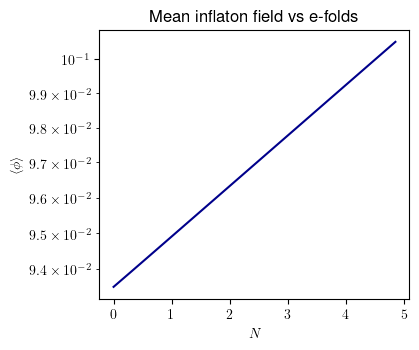

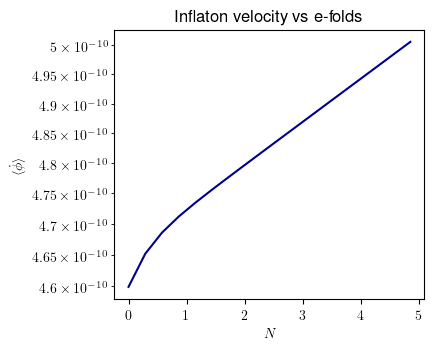

In [8]:
# Plot the time evolution of the inflaton mean value
plt.figure(figsize=(4, 3.5))
plt.semilogy(np.log(sf[:, 1]), f[:, 2], color='darkblue')
plt.ylabel(r'$\langle\phi\rangle$')
plt.xlabel(r'$N$')
plt.title("Mean inflaton field vs e-folds")
#plt.savefig('../plots/phi.pdf', dpi=300, bbox_inches='tight') 
plt.show()

# Plot the velocity of the inflaton field
plt.figure(figsize=(4, 3.5))
plt.semilogy(np.log(sf[:, 1]), np.abs(fv[:, 2]), color='darkblue')
plt.ylabel(r'$\langle\dot\phi\rangle$')
plt.xlabel(r'$N$')
plt.title("Inflaton velocity vs e-folds")
#plt.savefig('../plots/phidot.pdf', dpi=300, bbox_inches='tight') 
plt.show()


## 2) Power spectrum (linear estimate only)

With `deltaN` disabled, we only plot the linear estimate built from field fluctuations $\delta\phi$.


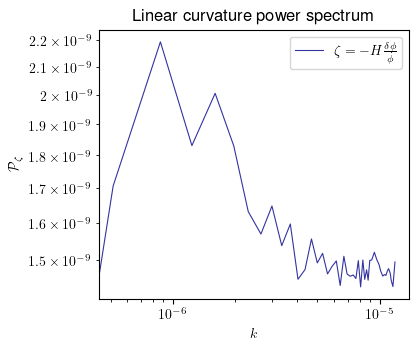

In [10]:
# Extract spectra over time
spectrum_list = [s[i:i+len(k_list), 2] for i in range(0, len(s[:, 0]), len(k_list))]

# Plot final linear curvature spectrum
cutoff_i = len(k_list) - 10
lowcutoff_i = 0

plt.figure(figsize=(4, 3.5))
plt.loglog(
    k_list[lowcutoff_i:cutoff_i],
    spectrum_list[-1][lowcutoff_i:cutoff_i] * k_list[lowcutoff_i:cutoff_i]**3 / (2 * np.pi**2) * (fv[-1, 2] / sf[-1, 2])**(-2),
    alpha=0.8,
    lw=0.8,
    color='darkblue',
    label=r'$\zeta=-H\frac{\delta\phi}{\dot\phi}$'
)

plt.ylabel(r'$\mathcal P_{\zeta}$')
plt.xlabel(r'$k$')
plt.legend()
plt.title("Linear curvature power spectrum")
#plt.savefig('../plots/spectrum.pdf', dpi=300, bbox_inches='tight')
plt.show()


We also visualize the time evolution of the inflaton power spectrum with a colorbar in e-folds.

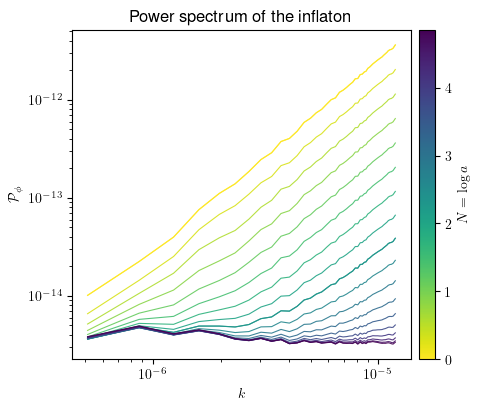

In [11]:
# Slice and mask k to avoid log10(0) errors
k_vals = k_list[lowcutoff_i:cutoff_i]
mask = k_vals > 0
k_vals = k_vals[mask]

# Pick time indices to plot (e.g. 20 evenly spaced snapshots)
n_steps = len(spectrum_list)
num_to_plot = 20
time_indices = np.linspace(0, n_steps - 1, num_to_plot, dtype=int)

# Compute e-folds N = log(a) at each index
efolds = np.log(sf[:, 1])
efolds_to_plot = efolds[time_indices]

# Normalize for colormap based on e-folds
norm = mcolors.Normalize(vmin=efolds_to_plot.min(), vmax=efolds_to_plot.max())
cmap = cm.viridis_r
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 4))

# Plot each spectrum snapshot
for t_idx, N in zip(time_indices, efolds_to_plot):
    spectrum = spectrum_list[t_idx][lowcutoff_i:cutoff_i][mask]
    power = spectrum * k_vals**3 / (2 * np.pi**2)
    ax.loglog(k_vals, power, color=cmap(norm(N)), lw=0.8, alpha=0.9)

# Axis labels
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\mathcal P_{\phi}$')

# Colorbar labeled by number of e-folds
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$N = \log a$')

# Layout and title
fig.tight_layout()
ax.set_title("Power spectrum of the inflaton")

# Show the plot
# fig.savefig('../plots/spectrum_evolution.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3) One-point PDF of inflaton fluctuations

With `deltaN` disabled, we show the inflaton PDF only.


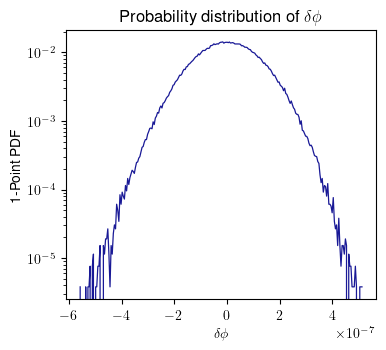

In [12]:
# Number of histogram bins
nbins = 256

# Parse inflaton PDF blocks
PDF_inflaton_n = [sh[i:i+nbins] for i in range(0, len(sh), nbins)]
PDF_inflaton_x = [sht[l,2] + sht[l,3] * np.linspace(0, nbins, nbins)
                  for l in range(len(PDF_inflaton_n))]

# Final-time inflaton PDF (mean-subtracted fluctuation)
mean_phi = np.sum(PDF_inflaton_x[-1] * PDF_inflaton_n[-1])
delta_phi = PDF_inflaton_x[-1] - mean_phi

plt.figure(figsize=(4, 3.5))
plt.semilogy(delta_phi, PDF_inflaton_n[-1], lw=0.9, alpha=0.9, color='darkblue')

plt.xlabel(r'$\delta\phi$')
plt.ylabel("1-Point PDF")
plt.title(r"Probability distribution of $\delta\phi$")
#plt.savefig('../plots/PDF.pdf', dpi=300, bbox_inches='tight') 
plt.show()


We also show how the inflaton PDF evolves over time.

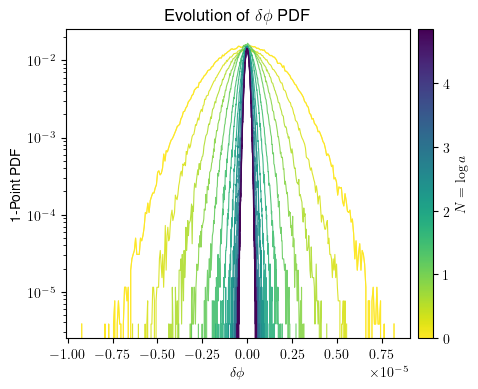

In [13]:
# Split the concatenated histogram data
PDF_inflaton_n = [sh[i:i+nbins] for i in range(0, len(sh), nbins)]
PDF_inflaton_x = [sht[l,2] + sht[l,3] * np.linspace(0, nbins, nbins) 
                  for l in range(len(PDF_inflaton_n))]

# Number of time steps (same as number of PDFs)
n_steps = len(PDF_inflaton_n)
num_to_plot = 20
time_indices = np.linspace(0, n_steps - 1, num_to_plot, dtype=int)

# Compute e-folds for coloring
efolds = np.log(sf[:, 1])
efolds_to_plot = efolds[time_indices]

# Normalize colormap using e-folds
norm = mcolors.Normalize(vmin=efolds_to_plot.min(), vmax=efolds_to_plot.max())
cmap = cm.viridis_r
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Plot
fig, ax = plt.subplots(figsize=(5, 4))

for t_idx, N in zip(time_indices, efolds_to_plot):
    x_phi = PDF_inflaton_x[t_idx]
    y_phi = PDF_inflaton_n[t_idx]
    mean_phi = np.sum(x_phi * y_phi)
    zeta_linear = x_phi - mean_phi
    ax.semilogy(zeta_linear, y_phi, lw=0.8, alpha=0.9, color=cmap(norm(N)))

ax.set_xlabel(r'$\delta\phi$')
ax.set_ylabel("1-Point PDF")
ax.set_title(r"Evolution of $\delta\phi$ PDF")

# Colorbar with e-folds
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$N = \log a$')

fig.tight_layout()
# fig.savefig('../plots/PDF_evolution.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4) Energy components

We monitor potential, kinetic, and gradient contributions.

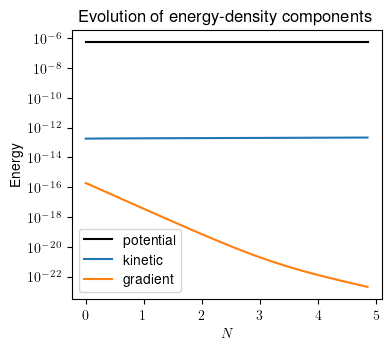

In [14]:
plt.figure(figsize=(4, 3.5))
plt.semilogy(np.log(energy[:, 1]), energy[:, 4],label='potential',color='black')
plt.semilogy(np.log(energy[:, 1]), energy[:, 2],label='kinetic')
plt.semilogy(np.log(energy[:, 1]), energy[:, 3],label='gradient')
plt.legend()
plt.xlabel(r'$N$')
plt.ylabel(r'Energy')
plt.title("Evolution of energy-density components")
#plt.savefig('../plots/energy.pdf', dpi=300, bbox_inches='tight') 
plt.show()

## 5) 2D real-space snapshot of the scalar field

We show the final 2D scalar-field configuration from `snapshots_2d_phi.dat`.


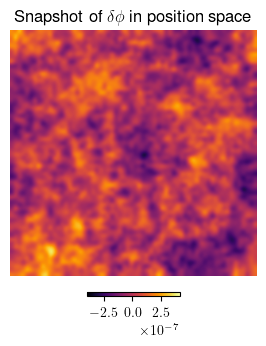

In [15]:
# Load 2D box snapshot of scalar field
phi_flat = np.loadtxt(path + 'snapshots_2d_phi.dat')
phi_flat = np.asarray(phi_flat).reshape(-1)

N = int(COMPILE_CONFIG['N'])
phi_timesteps = phi_flat[: (phi_flat.size // (N * N)) * (N * N)].reshape(-1, N, N)

# Final field and mean-subtracted fluctuation
phi_final = phi_timesteps[-1]
phi_final = phi_final - np.mean(phi_final)

# Normalize for colormap
valmax = np.max(phi_final)
valmin = np.min(phi_final)
norm = Normalize(vmin=valmin, vmax=valmax)

# Create colormap and plot
fig, ax = plt.subplots(figsize=(4, 4))
cmap = matplotlib.colormaps['inferno'].copy()
cmap.set_bad(color='green')

im = ax.imshow(phi_final, norm=norm, cmap=cmap, interpolation='bicubic')
ax.axis('off')
fig.colorbar(im, ax=ax, shrink=0.3, location='bottom', pad=0.05)
plt.title(r"Snapshot of $\delta\phi$ in position space")
#plt.savefig('../plots/snapshot.pdf', dpi=300, bbox_inches='tight') 
plt.show()


A 3D visualization of the same final snapshot.

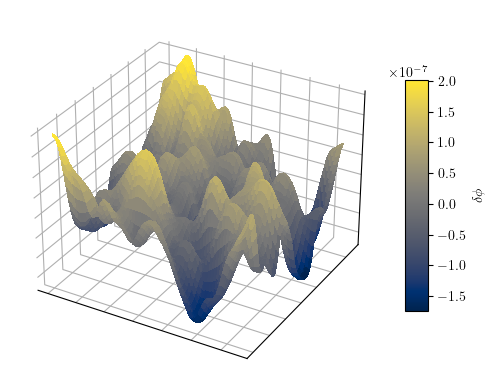

In [16]:
phi_flat = np.loadtxt(path + 'snapshots_2d_phi.dat')
phi_flat = np.asarray(phi_flat).reshape(-1)

N = int(COMPILE_CONFIG['N'])
phi_timesteps = phi_flat[: (phi_flat.size // (N * N)) * (N * N)].reshape(-1, N, N)
phi_final = phi_timesteps[-1]
phi_final = phi_final - np.mean(phi_final)

# Apply Gaussian smoothing
sigmaa = 2
box2d = gaussian_filter(phi_final, sigma=sigmaa)

# --- Prepare grid and colormap ---
Z = box2d
x = np.linspace(1, Z.shape[0], Z.shape[0])
y = np.linspace(1, Z.shape[1], Z.shape[1])
X, Y = np.meshgrid(x, y)

# Define colormap and normalization
cmap = cm.cividis
minn = np.nanmin(Z)
maxx = np.nanmax(Z)
norm = plt.Normalize(vmin=minn, vmax=maxx)
colors = cmap(norm(Z))

# --- Plot 3D surface ---
fig = plt.figure(figsize=(6, 6))
fig.patch.set_facecolor('white')  # Set figure background to white

ax = fig.add_subplot(111, projection='3d')

# Plot surface with color mapping
surf = ax.plot_surface(X, Y, Z, facecolors=colors, rstride=1, cstride=1,
                       antialiased=False, shade=False)

# Hide axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# Make tick marks fully transparent
ax.tick_params(axis='both', which='major', length=5, color=(0, 0, 0, 0))

# Set pane background to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Set overall axes background to white
ax.set_facecolor('white')

# Keep grid visible
ax.grid(True)

# --- Add colorbar ---
mappable = cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array(Z)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10)
cbar.set_label(r'$\delta\phi$')

# --- Display ---
plt.show()


## How to switch features/examples

In the configuration cell, you can change:

- `COMPILE_CONFIG['numerical_potential'] = 1` to use the numerical example
- `PRESET_FILE = 'params.numerical.txt'` for the matching run-time preset
- `COMPILE_CONFIG['N'] = ...` to choose your lattice size
- `COMPILE_CONFIG['perform_deltaN'] = 1` to enable `deltaN`
- `COMPILE_CONFIG['calculate_SIGW'] = 1` and `COMPILE_CONFIG['post_inflation'] = 1` to enable GW/post-inflation outputs
- (optional) adjust `RUNTIME_OVERRIDES` and `CASE_NAME`

Then run the notebook again from the run cell.
